In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
x_train = pd.read_csv("/Users/sami/Documents/CS Postgrad/IDS/COIY065D7_Anomaly-Based-IDS/Data/x_train.csv")
x_test = pd.read_csv("/Users/sami/Documents/CS Postgrad/IDS/COIY065D7_Anomaly-Based-IDS/Data/x_test.csv")
x_validation = pd.read_csv("/Users/sami/Documents/CS Postgrad/IDS/COIY065D7_Anomaly-Based-IDS/Data/x_validation.csv")
y_test = pd.read_csv("/Users/sami/Documents/CS Postgrad/IDS/COIY065D7_Anomaly-Based-IDS/Data/y_test.csv").squeeze()

In [4]:
model = IsolationForest(random_state = 42)
model.fit(x_train)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [5]:
val_scores =  model.decision_function(x_validation)
print(val_scores[:20])

[ 0.14879343  0.13946595  0.09639425  0.14626624  0.08933538  0.09654686
  0.14345227  0.14677467  0.0946551   0.0063272   0.1231535   0.10882425
 -0.00808308  0.14868938 -0.0118978   0.03472268  0.09168862  0.05866111
  0.14095005  0.12172309]


In [6]:
first_threshold = np.percentile(val_scores, 1)
second_threshold = np.percentile(val_scores, 2)
third_threshold = np.percentile(val_scores, 5)

In [7]:
print("One percent threshold: ", first_threshold)
print("Two percent threshold: ", second_threshold)
print("Five percent threshold: ", third_threshold)

One percent threshold:  -0.046609957895855765
Two percent threshold:  -0.028090152990841808
Five percent threshold:  0.0022925800425738388


In [10]:
test_scores = model.decision_function(x_test)
print(test_scores[:20])

[ 0.0416699   0.14239239  0.06836158  0.14757981  0.09456836  0.10246234
  0.14458188  0.14642783  0.1513442   0.12939094  0.05560693  0.07078372
  0.14310105  0.08664995 -0.01878001  0.13990531  0.03792263  0.06008164
  0.14860955  0.14596902]


In [18]:
first_y_prediction = (test_scores < first_threshold).astype(int)
print(first_y_prediction[:40])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0]


In [19]:
second_y_prediction = (test_scores < second_threshold).astype(int)
print(second_y_prediction[:40])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0]


In [20]:
third_y_prediction = (test_scores < third_threshold).astype(int)
print(third_y_prediction[:40])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0]


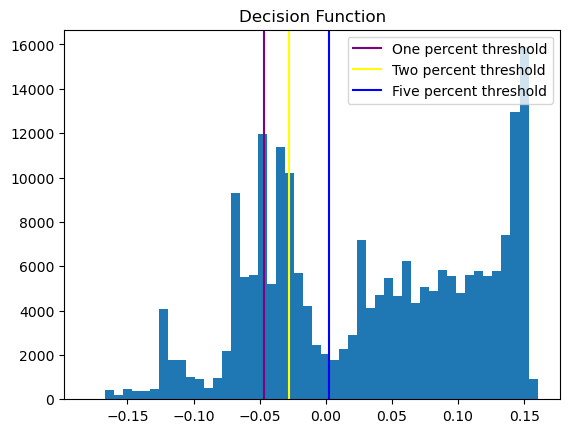

In [31]:
plt.hist(test_scores, bins = 50)
plt.axvline(first_threshold, color = "purple", label = "One percent threshold")
plt.axvline(second_threshold, color = "yellow", label = "Two percent threshold")
plt.axvline(third_threshold, color = "blue", label = "Five percent threshold")
plt.title("Decision Function")
plt.x_label = ("Anomaly score")
plt.y_label = ("Number of samples")
plt.legend()
plt.show()